# 2e. Calculate closed-system degassing paths for different volatile systems.

These are some examples where the volatiles aren't C, H, and S. These types of calculations can be done for open- and closed-system, re- and degassing paths as described in Examples 2a-d, but we'll just show them for closed-system degassing paths where the inputted composition represents the bulk composition of the system.

## Python set-up
You need to install VolFe once on your machine, if you haven't yet. Then we need to import a few Python packages (including VolFe). 

In [1]:
# Install VolFe on your machine. Remove the # from line below to do this (don't remove the # from this line!).
# pip install VolFe

In [2]:
# Install VolFe on your machine. Don't remove the # from this line!
# pip install VolFe # Remove the first # in this line if you have not installed VolFe on your machine before.

# import python packages
import pandas as pd
import matplotlib.pyplot as plt
import VolFe as vf

In [3]:
# VolFe version
vf.__version__

'0.4.1'

## Define the inputs

For the volatile-free melt composition, we'll use Sari15-04-33 from Brounce et al. (2014) with the updated Fe<sup>3+</sup>/Fe<sub>T</sub> from Cottrell et al. (2021) at 1200 °C as before, but we will specify different volatile concentrations. 

First, we'll model CHOAr degassing - i.e., carbon, hydrogen, and argon are the volatiles of interest (no sulfur - at the moment it isn't possible to run CHOS and a noble gas).

In this case the initial volatile content is 500 ppm CO<sub>2</sub>, 2 wt% H<sub>2</sub>O, and 10 ppm Ar.

The Ar amount is inputted for the "X" species.

In [4]:
# Define the melt composition, fO2 estimate, and T as a dictionary.
my_analysis = {'Sample':'Sari15-04-33',
           'T_C': 1200., # Temperature in 'C
           'SiO2': 47.89, # wt%
           'TiO2': 0.75, # wt%
           'Al2O3': 16.74, # wt%
           'FeOT': 9.43, # wt%
           'MnO': 0.18, # wt%
           'MgO': 5.92, # wt%
           'CaO': 11.58, # wt%
           'Na2O': 2.14, # wt%
           'K2O': 0.63, # wt%
           'P2O5': 0.17, # wt%
           'H2O': 2., # wt%
           'CO2ppm': 500., # ppm
           'STppm': 0., # ppm
           'Xppm': 10., # ppm <<< treating this as Ar
           'Fe3FeT': 0.177}

# Turn the dictionary into a pandas dataframe, setting the index to 0.
my_analysis = pd.DataFrame(my_analysis, index=[0])

We'll use the default options, but the important options for noble gas modelling are:

**species X** where the default is Ar (*Ar*)

**species X solubility** where the default is for Ar in basalt (*Ar_Basalt_Hughes25*)

Both these defaults are fine for this example, but you can change them to Ar in rhyolite (*Ar_Rhyolite_Hughes25*) or Ne (*Ne*) for basalt (*Ne_Basalt_Hughes25*) or rhyolite (*Ne_Rhyolite_Hughes25*).

## Run the calculation

### Ar in basalt

In [5]:
degas1 = vf.calc_gassing(my_analysis)

100%|█████████▉| 1399.0/1400 [00:51<00:00, 27.29it/s] 


### Ne in basalt

Next for Ne in basalt

In [ ]:
# choose the options I want - everything else will use the default options
my_models = [['species X','Ne'],['species X solubility','Ne_Basalt_Hughes25']]

# turn to dataframe with correct column headers and indexes    
my_models = vf.make_df_and_add_model_defaults(my_models)

# run calculation
degas2 = vf.calc_gassing(my_analysis,models=my_models)

100%|█████████▉| 1399.0/1400 [00:54<00:00, 25.51it/s] 


### Ar in rhyolite

Or Ar in rhyolite

In [ ]:
# choose the options I want - everything else will use the default options
my_models = [['species X solubility','Ar_Rhyolite_Hughes25']]

# turn to dataframe with correct column headers and indexes    
my_models = vf.make_df_and_add_model_defaults(my_models)

# run calculation
degas3 = vf.calc_gassing(my_analysis,models=my_models)

100%|█████████▉| 1299.0/1300 [00:47<00:00, 27.58it/s] 


### Plotting

And plot for comparison.

(1500.0, 0.0)

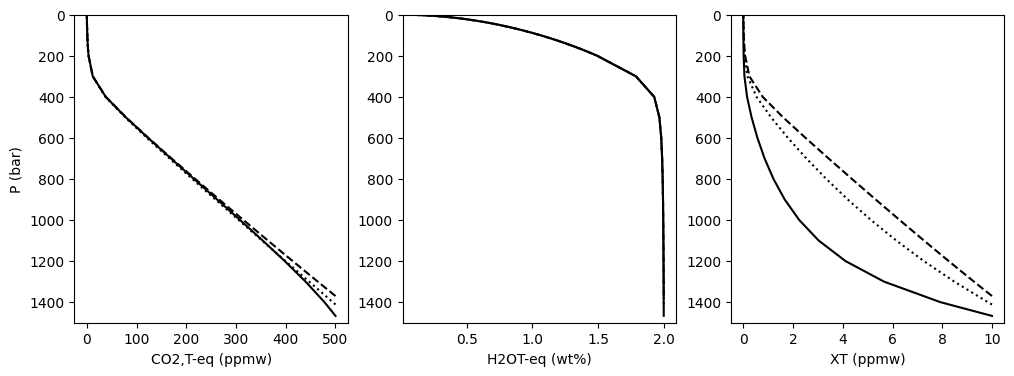

In [8]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(12,4))

data1 = degas1 # Ar in basalt
data2 = degas2 # Ne in basalt
data3 = degas3 # Ar in rhyolite

# Plotting results
ax1.plot(data1['CO2T-eq_ppmw'], data1['P_bar'], '-k')
ax1.plot(data2['CO2T-eq_ppmw'], data2['P_bar'], ':k')
ax1.plot(data3['CO2T-eq_ppmw'], data3['P_bar'], '--k')
ax2.plot(data1['H2OT-eq_wtpc'], data1['P_bar'], '-k')
ax2.plot(data2['H2OT-eq_wtpc'], data2['P_bar'], ':k')
ax2.plot(data3['H2OT-eq_wtpc'], data3['P_bar'], '--k')
ax3.plot(data1['X_ppmw'], data1['P_bar'], '-k')
ax3.plot(data2['X_ppmw'], data2['P_bar'], ':k')
ax3.plot(data3['X_ppmw'], data3['P_bar'], '--k')

ax1.set_ylabel('P (bar)')
ax1.set_xlabel('CO2,T-eq (ppmw)')
ax2.set_xlabel('H2OT-eq (wt%)')
ax3.set_xlabel('XT (ppmw)')
ax1.set_ylim([1500,0])
ax2.set_ylim([1500,0])
ax3.set_ylim([1500,0])

### HSO system

Alternatively, we could just look at degassing in the HSO system (i.e., no CO<sub>2</sub> or X)

In [9]:
# Define the melt composition, fO2 estimate, and T as a dictionary.
my_analysis = {'Sample':'Sari15-04-33',
           'T_C': 1200., # Temperature in 'C
           'SiO2': 47.89, # wt%
           'TiO2': 0.75, # wt%
           'Al2O3': 16.74, # wt%
           'FeOT': 9.43, # wt%
           'MnO': 0.18, # wt%
           'MgO': 5.92, # wt%
           'CaO': 11.58, # wt%
           'Na2O': 2.14, # wt%
           'K2O': 0.63, # wt%
           'P2O5': 0.17, # wt%
           'H2O': 2., # wt%
           'CO2ppm': 0., # ppm
           'STppm': 1000., # ppm
           'Xppm': 0., # ppm
           'Fe3FeT': 0.177}

# Turn the dictionary into a pandas dataframe, setting the index to 0.
my_analysis = pd.DataFrame(my_analysis, index=[0])

In [10]:
degas4 = vf.calc_gassing(my_analysis)

100%|█████████▉| 299.0/300 [00:06<00:00, 43.82it/s] 


### CSO system

Or CSO system

In [11]:
# Define the melt composition, fO2 estimate, and T as a dictionary.
my_analysis = {'Sample':'Sari15-04-33',
           'T_C': 1200., # Temperature in 'C
           'SiO2': 47.89, # wt%
           'TiO2': 0.75, # wt%
           'Al2O3': 16.74, # wt%
           'FeOT': 9.43, # wt%
           'MnO': 0.18, # wt%
           'MgO': 5.92, # wt%
           'CaO': 11.58, # wt%
           'Na2O': 2.14, # wt%
           'K2O': 0.63, # wt%
           'P2O5': 0.17, # wt%
           'H2O': 0., # wt%
           'CO2ppm': 500., # ppm
           'STppm': 1000., # ppm
           'Xppm': 0., # ppm
           'Fe3FeT': 0.177}

# Turn the dictionary into a pandas dataframe, setting the index to 0.
my_analysis = pd.DataFrame(my_analysis, index=[0])

In [12]:
degas5 = vf.calc_gassing(my_analysis)

100%|█████████▉| 999.0/1000 [00:13<00:00, 71.53it/s] 


### Plotting

And compare!

(1200.0, 0.0)

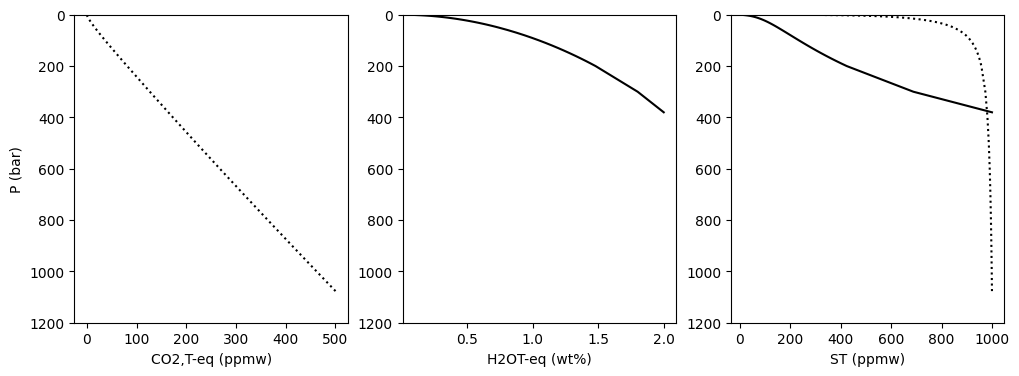

In [13]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(12,4))

data1 = degas4 # HSO
data2 = degas5 # CSO

# Plotting results
ax1.plot(data2['CO2T-eq_ppmw'], data2['P_bar'], ':k')
ax2.plot(data1['H2OT-eq_wtpc'], data1['P_bar'], '-k')
ax3.plot(data1['ST_ppmw'], data1['P_bar'], '-k')
ax3.plot(data2['ST_ppmw'], data2['P_bar'], ':k')

ax1.set_ylabel('P (bar)')
ax1.set_xlabel('CO2,T-eq (ppmw)')
ax2.set_xlabel('H2OT-eq (wt%)')
ax3.set_xlabel('ST (ppmw)')
ax1.set_ylim([1200,0])
ax2.set_ylim([1200,0])
ax3.set_ylim([1200,0])